# Nascimentos: prematuridade, pré-natal e a epidemia de cesáreas

**A pergunta:** o Brasil tem uma das maiores taxas de cesárea do mundo e uma
prematuridade que não cede. Onde exatamente isso acontece, com quem, e o
pré-natal está chegando a quem mais precisa?

**Fonte:** Sistema de Informações sobre Nascidos Vivos (SINASC/DATASUS) — a
declaração de nascido vivo de cada bebê nascido no país.

**Tempo estimado:** 5 a 8 minutos.

**O que você leva daqui:** a classificação de Robson (o padrão da OMS para
comparar taxas de cesárea entre serviços sem injustiça), os indicadores de
prematuridade e baixo peso calculados como manda a OMS, e o gradiente social
de todos eles.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
UF = "PR"       # estado analisado
ANOS_SERIE = 8  # tamanho da série histórica

print(f"Estado analisado: {UF}")

Estado analisado: PR


## 2. Quais anos existem

O SINASC fecha um ano cerca de um ano e meio depois. Pedir um ano que ainda não
existe devolve tabela vazia, sem erro — por isso perguntamos ao catálogo.

In [5]:
from pysus import list_files, sinasc

catalogo = list_files(dataset="sinasc", state=UF)
anos = sorted(int(a) for a in catalogo["year"].dropna().unique())

ANO = anos[-1]
serie = [a for a in anos if a > ANO - ANOS_SERIE]

print(f"Anos disponíveis para {UF}: {anos[0]} a {anos[-1]}")
print(f"Ano de referência: {ANO}")
print(f"Série: {serie[0]} a {serie[-1]}")

Anos disponíveis para PR: 1994 a 2022
Ano de referência: 2022
Série: 2015 a 2022


## 3. O que a declaração de nascido vivo registra

A DN mudou ao longo dos anos: campos foram criados, outros ficaram obsoletos.
Em vez de supor que uma coluna existe, **perguntamos ao arquivo** — assim o
notebook continua funcionando em anos e estados diferentes.

In [6]:
arquivo = sinasc(UF, ANO)[0].replace("\\", "/")

descricao = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{arquivo}')").df()
disponiveis = set(descricao["column_name"])
total = con.execute(f"SELECT count(*) FROM read_parquet('{arquivo}')").fetchone()[0]

INTERESSE = {
    "PESO": "peso ao nascer, em gramas",
    "SEMAGESTAC": "semanas de gestação (número)",
    "GESTACAO": "faixa de semanas de gestação (código)",
    "PARTO": "1 vaginal, 2 cesáreo",
    "TPROBSON": "grupo de Robson, já calculado pelo Ministério da Saúde",
    "CONSPRENAT": "número de consultas de pré-natal",
    "CONSULTAS": "faixa de consultas de pré-natal (código)",
    "MESPRENAT": "mês de gestação em que o pré-natal começou",
    "KOTELCHUCK": "índice de adequação do pré-natal",
    "IDADEMAE": "idade da mãe",
    "ESCMAE2010": "escolaridade da mãe",
    "RACACOR": "raça/cor do bebê",
    "APGAR5": "Apgar no 5º minuto",
    "QTDPARTCES": "cesáreas anteriores",
    "QTDPARTNOR": "partos vaginais anteriores",
    "GRAVIDEZ": "1 única, 2 dupla, 3 tripla ou mais",
    "CODMUNRES": "município de residência da mãe",
    "LOCNASC": "local do nascimento (1 hospital, 3 domicílio)",
}

print(f"{UF} em {ANO}: {mil(total)} nascidos vivos")
print(f"A declaração tem {len(descricao)} campos. Dos que interessam:\n")
for coluna, papel in INTERESSE.items():
    marca = "presente" if coluna in disponiveis else "AUSENTE "
    print(f"  [{marca}] {coluna:<12} {papel}")

PR em 2022: 140.637 nascidos vivos
A declaração tem 61 campos. Dos que interessam:

  [presente] PESO         peso ao nascer, em gramas
  [presente] SEMAGESTAC   semanas de gestação (número)
  [presente] GESTACAO     faixa de semanas de gestação (código)
  [presente] PARTO        1 vaginal, 2 cesáreo
  [presente] TPROBSON     grupo de Robson, já calculado pelo Ministério da Saúde
  [presente] CONSPRENAT   número de consultas de pré-natal
  [presente] CONSULTAS    faixa de consultas de pré-natal (código)
  [presente] MESPRENAT    mês de gestação em que o pré-natal começou
  [presente] KOTELCHUCK   índice de adequação do pré-natal
  [presente] IDADEMAE     idade da mãe
  [presente] ESCMAE2010   escolaridade da mãe
  [presente] RACACOR      raça/cor do bebê
  [presente] APGAR5       Apgar no 5º minuto
  [presente] QTDPARTCES   cesáreas anteriores
  [presente] QTDPARTNOR   partos vaginais anteriores
  [presente] GRAVIDEZ     1 única, 2 dupla, 3 tripla ou mais
  [presente] CODMUNRES    muni

In [7]:
colunas = [c for c in INTERESSE if c in disponiveis]
nascimentos = con.execute(
    f"SELECT {', '.join(colunas)} FROM read_parquet('{arquivo}')"
).df()

for coluna in ["PESO", "SEMAGESTAC", "IDADEMAE", "CONSPRENAT", "APGAR5",
               "MESPRENAT", "QTDPARTCES", "QTDPARTNOR"]:
    if coluna in nascimentos:
        nascimentos[coluna] = pd.to_numeric(nascimentos[coluna], errors="coerce")

print(f"{mil(len(nascimentos))} registros carregados")
nascimentos.head(3)

140.637 registros carregados


,PESO,SEMAGESTAC,GESTACAO,PARTO,TPROBSON,CONSPRENAT,CONSULTAS,MESPRENAT,KOTELCHUCK,IDADEMAE,ESCMAE2010,RACACOR,APGAR5,QTDPARTCES,QTDPARTNOR,GRAVIDEZ,CODMUNRES,LOCNASC
0,3010.0,38.0,5,2,05,1.0,2,1.0,2,24,4,4,9.0,1.0,0.0,1,411460,1
1,3055.0,38.0,5,2,05,12.0,4,1.0,5,26,5,2,9.0,1.0,0.0,1,410690,1
2,3172.0,36.0,4,2,10,8.0,4,1.0,5,26,3,1,9.0,1.0,0.0,1,410580,1


## 4. Prematuridade e peso ao nascer

Duas definições da OMS, usadas no mundo inteiro:

- **Prematuro**: menos de 37 semanas completas de gestação.
- **Baixo peso**: menos de 2.500 g. Abaixo de 1.500 g, **muito baixo peso** — a
  faixa que concentra a mortalidade neonatal.

O SINASC traz as semanas de duas formas: o número exato (`SEMAGESTAC`) e uma
faixa em código (`GESTACAO`). O número é melhor, mas falta em parte dos
registros; a faixa cobre o resto.

In [8]:
FAIXA_GESTACAO = {      # código do campo GESTACAO
    "1": 21, "2": 25, "3": 30, "4": 34, "5": 39, "6": 42,
}

def semanas_de_gestacao(linha):
    """Semanas de gestação, preferindo o número e caindo para a faixa."""
    valor = linha.get("SEMAGESTAC")
    if pd.notna(valor) and 15 <= valor <= 45:
        return float(valor)
    codigo = str(linha.get("GESTACAO", "")).strip()
    return FAIXA_GESTACAO.get(codigo, np.nan)

nascimentos["semanas"] = nascimentos.apply(semanas_de_gestacao, axis=1)
nascimentos["prematuro"] = nascimentos["semanas"] < 37
nascimentos["peso_valido"] = nascimentos["PESO"].between(200, 7000)

com_semanas = nascimentos["semanas"].notna()
com_peso = nascimentos["peso_valido"]

indicadores = {
    "Prematuridade (< 37 semanas)":
        nascimentos.loc[com_semanas, "prematuro"].mean() * 100,
    "Prematuridade extrema (< 32 semanas)":
        (nascimentos.loc[com_semanas, "semanas"] < 32).mean() * 100,
    "Baixo peso (< 2.500 g)":
        (nascimentos.loc[com_peso, "PESO"] < 2500).mean() * 100,
    "Muito baixo peso (< 1.500 g)":
        (nascimentos.loc[com_peso, "PESO"] < 1500).mean() * 100,
}

referencia = {
    "Prematuridade (< 37 semanas)": 11.0,
    "Prematuridade extrema (< 32 semanas)": 1.6,
    "Baixo peso (< 2.500 g)": 8.6,
    "Muito baixo peso (< 1.500 g)": 1.4,
}

resumo = pd.DataFrame({
    f"{UF} em {ANO} (%)": pd.Series(indicadores).round(2),
    "Brasil, referência (%)": pd.Series(referencia),
})
print(f"Registros sem informação de gestação: "
      f"{(~com_semanas).mean() * 100:.1f}%")
print(f"Registros sem peso válido: {(~com_peso).mean() * 100:.1f}%\n")
resumo

Registros sem informação de gestação: 0.5%
Registros sem peso válido: 0.0%



,PR em 2022 (%),"Brasil, referência (%)"
Prematuridade (< 37 semanas),11.23,11.0
Prematuridade extrema (< 32 semanas),1.48,1.6
Baixo peso (< 2.500 g),9.36,8.6
Muito baixo peso (< 1.500 g),1.44,1.4


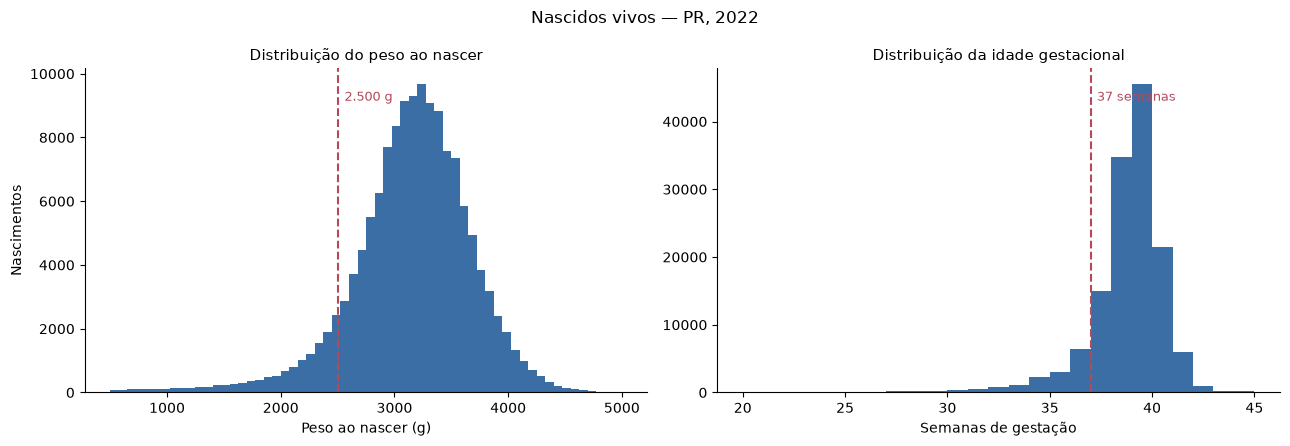

In [9]:
validos = nascimentos[com_peso]

figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 4.5))

eixo1.hist(validos["PESO"], bins=60, range=(500, 5000), color="#3b6ea5")
eixo1.axvline(2500, color="#b5495b", linestyle="--", linewidth=1.5)
eixo1.text(2560, eixo1.get_ylim()[1] * 0.9, "2.500 g", color="#b5495b", fontsize=9)
eixo1.set_xlabel("Peso ao nascer (g)")
eixo1.set_ylabel("Nascimentos")
eixo1.set_title("Distribuição do peso ao nascer", fontsize=11)

semanas = nascimentos.loc[com_semanas, "semanas"]
eixo2.hist(semanas, bins=range(20, 46), color="#3b6ea5")
eixo2.axvline(37, color="#b5495b", linestyle="--", linewidth=1.5)
eixo2.text(37.3, eixo2.get_ylim()[1] * 0.9, "37 semanas", color="#b5495b", fontsize=9)
eixo2.set_xlabel("Semanas de gestação")
eixo2.set_title("Distribuição da idade gestacional", fontsize=11)

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Nascidos vivos — {UF}, {ANO}", fontsize=12)
plt.tight_layout()
plt.show()

Repare no pico logo antes das 39 semanas no gráfico da direita. Ele não é
biológico: é o efeito das cesáreas e induções agendadas, que concentram
nascimentos em dias úteis e em idades gestacionais escolhidas.

## 5. Cesáreas: a taxa e o que ela esconde

A taxa bruta de cesárea de um hospital não diz se ele opera demais. Um serviço
de referência que recebe gestações de risco vai operar mais — e deve.

A **classificação de Robson**, adotada pela OMS, resolve isso: separa todas as
gestantes em dez grupos por características que se sabem antes do parto
(número de partos anteriores, cesárea prévia, apresentação, gemelaridade,
idade gestacional e se o trabalho de parto começou sozinho). Comparam-se então
os grupos, e não os totais.

O grupo que mais importa é o **Robson 5** — mulheres com cesárea anterior —
porque no Brasil a primeira cesárea determina quase todas as seguintes.

In [10]:
cesarea = nascimentos["PARTO"].astype(str).str.strip()
taxa_cesarea = (cesarea == "2").sum() / cesarea.isin(["1", "2"]).sum() * 100

print(f"Taxa de cesárea — {UF}, {ANO}: {taxa_cesarea:.1f}%")
print()
print("Para comparar:")
print("  OMS considera que acima de 10-15% não há benefício populacional")
print("  Brasil, rede como um todo: cerca de 57%")
print("  Rede pública: cerca de 45%   |   Rede privada: acima de 80%")

Taxa de cesárea — PR, 2022: 64.8%



Para comparar:
  OMS considera que acima de 10-15% não há benefício populacional
  Brasil, rede como um todo: cerca de 57%
  Rede pública: cerca de 45%   |   Rede privada: acima de 80%


In [11]:
ROBSON = {
    1: "1. Primeira gestação, único, cefálico, ≥37 sem, parto espontâneo",
    2: "2. Primeira gestação, único, cefálico, ≥37 sem, induzido ou cesárea antes do parto",
    3: "3. Com partos anteriores, sem cesárea, único, cefálico, ≥37 sem, espontâneo",
    4: "4. Com partos anteriores, sem cesárea, único, cefálico, ≥37 sem, induzido ou cesárea antes",
    5: "5. Cesárea anterior, único, cefálico, ≥37 semanas",
    6: "6. Primeira gestação, pélvico",
    7: "7. Com partos anteriores, pélvico",
    8: "8. Gestações múltiplas",
    9: "9. Situação transversa ou oblíqua",
    10: "10. Único, cefálico, menos de 37 semanas",
}

if "TPROBSON" in nascimentos:
    grupo = pd.to_numeric(nascimentos["TPROBSON"], errors="coerce")
    origem_robson = "calculado pelo Ministério da Saúde (campo TPROBSON)"
else:
    grupo = pd.Series(np.nan, index=nascimentos.index)
    origem_robson = "campo TPROBSON ausente neste ano"

nascimentos["robson"] = grupo
cobertura = grupo.between(1, 10).mean() * 100
print(f"Grupo de Robson: {origem_robson}")
print(f"Classificados de 1 a 10: {cobertura:.1f}% dos nascimentos")
print(f"Código 11 (sem classificação possível): "
      f"{(grupo == 11).mean() * 100:.1f}%")

Grupo de Robson: calculado pelo Ministério da Saúde (campo TPROBSON)
Classificados de 1 a 10: 98.4% dos nascimentos
Código 11 (sem classificação possível): 1.6%


Antes de confiar no campo pronto, vale conferir se ele significa o que
dizemos. O grupo 5 é definido como "mulheres com cesárea anterior" — então a
imensa maioria das classificadas nele deve ter pelo menos uma cesárea prévia
registrada em outro campo. Se isso não bater, a interpretação está errada.

In [12]:
if {"QTDPARTCES"}.issubset(nascimentos.columns):
    grupo5 = nascimentos["robson"] == 5
    com_cesarea_previa = nascimentos["QTDPARTCES"] >= 1
    concordancia = com_cesarea_previa[grupo5].mean() * 100
    fora = com_cesarea_previa[~grupo5 & nascimentos["robson"].between(1, 10)].mean() * 100
    print(f"No grupo 5, têm cesárea anterior registrada: {concordancia:.1f}%")
    print(f"Nos demais grupos, têm cesárea anterior:     {fora:.1f}%")
    print()
    print("O contraste confirma que o campo significa o que esperamos.")

No grupo 5, têm cesárea anterior registrada: 100.0%
Nos demais grupos, têm cesárea anterior:     6.6%

O contraste confirma que o campo significa o que esperamos.


In [13]:
tabela_robson = (
    nascimentos[nascimentos["robson"].between(1, 10)]
    .assign(cesarea=lambda d: d["PARTO"].astype(str).str.strip() == "2")
    .groupby("robson")
    .agg(Nascimentos=("cesarea", "size"), Cesáreas=("cesarea", "sum"))
)
tabela_robson["% do total de partos"] = (
    tabela_robson["Nascimentos"] / tabela_robson["Nascimentos"].sum() * 100).round(1)
tabela_robson["Taxa de cesárea (%)"] = (
    tabela_robson["Cesáreas"] / tabela_robson["Nascimentos"] * 100).round(1)
tabela_robson["Contribuição para a taxa geral (%)"] = (
    tabela_robson["Cesáreas"] / tabela_robson["Nascimentos"].sum() * 100).round(1)
tabela_robson.index = [ROBSON.get(int(i), i) for i in tabela_robson.index]

tabela_robson.sort_values("Contribuição para a taxa geral (%)", ascending=False)

,Nascimentos,Cesáreas,% do total de partos,Taxa de cesárea (%),Contribuição para a taxa geral (%)
"5. Cesárea anterior, único, cefálico, ≥37 semanas",40039,35172,28.9,87.8,25.4
"2. Primeira gestação, único, cefálico, ≥37 sem, induzido ou cesárea antes do parto",23345,18333,16.9,78.5,13.2
"1. Primeira gestação, único, cefálico, ≥37 sem, parto espontâneo",19674,9656,14.2,49.1,7.0
"4. Com partos anteriores, sem cesárea, único, cefálico, ≥37 sem, induzido ou cesárea antes",14511,8044,10.5,55.4,5.8
"10. Único, cefálico, menos de 37 semanas",12296,7491,8.9,60.9,5.4
"3. Com partos anteriores, sem cesárea, único, cefálico, ≥37 sem, espontâneo",20424,3722,14.8,18.2,2.7
8. Gestações múltiplas,3336,2985,2.4,89.5,2.2
"7. Com partos anteriores, pélvico",2640,2400,1.9,90.9,1.7
"6. Primeira gestação, pélvico",1864,1731,1.3,92.9,1.3
9. Situação transversa ou oblíqua,280,271,0.2,96.8,0.2


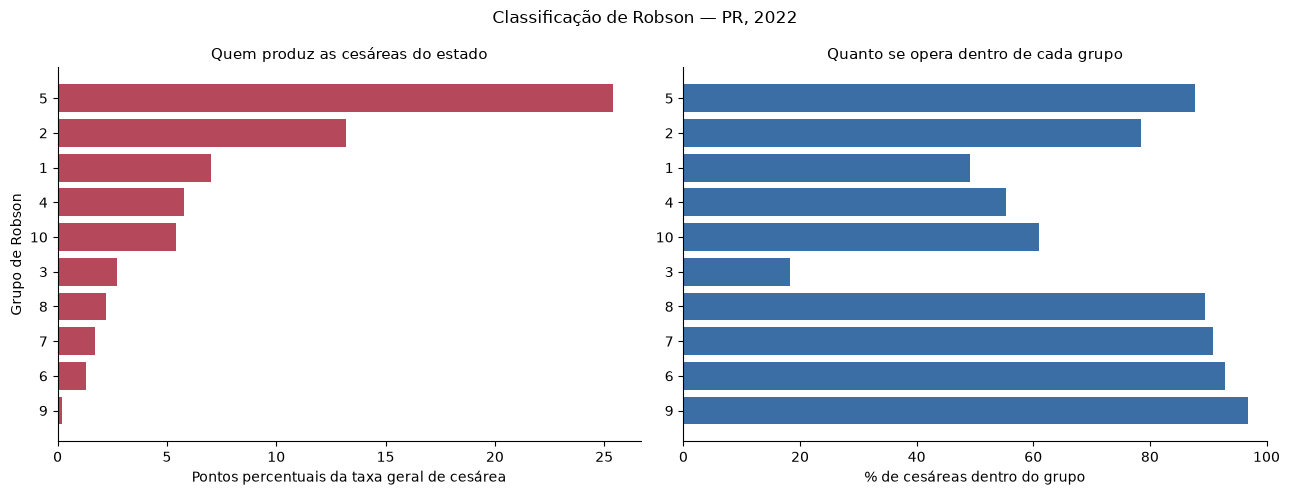

In [14]:
ordenado = tabela_robson.sort_values("Contribuição para a taxa geral (%)")
rotulos = [i.split(".")[0] for i in ordenado.index]

figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 5))

eixo1.barh(rotulos, ordenado["Contribuição para a taxa geral (%)"], color="#b5495b")
eixo1.set_xlabel("Pontos percentuais da taxa geral de cesárea")
eixo1.set_title("Quem produz as cesáreas do estado", fontsize=11)
eixo1.set_ylabel("Grupo de Robson")

eixo2.barh(rotulos, ordenado["Taxa de cesárea (%)"], color="#3b6ea5")
eixo2.set_xlabel("% de cesáreas dentro do grupo")
eixo2.set_title("Quanto se opera dentro de cada grupo", fontsize=11)
eixo2.set_xlim(0, 100)

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Classificação de Robson — {UF}, {ANO}", fontsize=12)
plt.tight_layout()
plt.show()

A leitura clássica: os grupos **1, 2 e 5** costumam responder por dois terços
das cesáreas. E o 5 é consequência dos outros dois — cada primeira cesárea
evitável hoje é um Robson 5 daqui a alguns anos. É por isso que política de
parto se faz olhando o grupo 1.

## 6. O pré-natal chegou?

O Ministério da Saúde recomenda **no mínimo seis consultas**, começando no
primeiro trimestre. O SINASC permite verificar as duas coisas.

In [15]:
FAIXA_CONSULTAS = {"1": "Nenhuma", "2": "1 a 3", "3": "4 a 6", "4": "7 ou mais"}

if "CONSPRENAT" in nascimentos:
    consultas = nascimentos["CONSPRENAT"]
    adequadas = (consultas >= 6)
    valido = consultas.notna() & (consultas <= 30)
    print(f"Consultas de pré-natal (número exato) — média: {consultas[valido].mean():.1f}")
    print(f"Com seis ou mais consultas: {adequadas[valido].mean() * 100:.1f}%")
else:
    faixa = nascimentos["CONSULTAS"].astype(str).str.strip()
    valido = faixa.isin(FAIXA_CONSULTAS)
    adequadas = faixa.isin(["4"])
    print(f"Com sete ou mais consultas: {adequadas[valido].mean() * 100:.1f}%")

if "MESPRENAT" in nascimentos:
    inicio = nascimentos["MESPRENAT"]
    precoce = (inicio <= 3)
    valido_inicio = inicio.between(1, 9)
    print(f"Pré-natal iniciado no primeiro trimestre: "
          f"{precoce[valido_inicio].mean() * 100:.1f}%")
    print(f"Sem informação do mês de início: {(~valido_inicio).mean() * 100:.1f}%")

print()
print("Referência nacional: cerca de 75% das gestantes fazem sete ou mais")
print("consultas, e cerca de 70% começam no primeiro trimestre.")

Consultas de pré-natal (número exato) — média: 9.8


Com seis ou mais consultas: 91.6%
Pré-natal iniciado no primeiro trimestre: 88.8%
Sem informação do mês de início: 2.1%

Referência nacional: cerca de 75% das gestantes fazem sete ou mais
consultas, e cerca de 70% começam no primeiro trimestre.


### O índice de Kotelchuck, e como conferir um campo que veio pronto

O SINASC traz o índice de Kotelchuck já calculado — ele combina o mês de início
com o número de consultas esperado para a idade gestacional, e é o padrão
internacional para dizer se o pré-natal foi adequado.

O campo vem como número, e a tentação é decorar a legenda. **Não decore:
confira.** A tabela abaixo mostra, para cada código, quantas consultas e em que
mês o pré-natal começou — os ingredientes com que o índice foi construído.

In [16]:
KOTELCHUCK = {
    "1": "Não fez pré-natal",
    "2": "Inadequado",
    "3": "Intermediário",
    "4": "Adequado",
    "5": "Mais que adequado",
    "9": "Sem classificação",
}

if "KOTELCHUCK" in nascimentos:
    base_k = nascimentos.assign(
        codigo=nascimentos["KOTELCHUCK"].astype(str).str.strip(),
        consultas_validas=nascimentos["CONSPRENAT"].where(
            nascimentos["CONSPRENAT"].between(0, 30)),
        mes_valido=nascimentos["MESPRENAT"].where(
            nascimentos["MESPRENAT"].between(1, 9)),
    )
    prova = (
        base_k.groupby("codigo")
        .agg(**{
            "Nascimentos": ("PESO", "size"),
            "% do total": ("PESO", lambda s: len(s) / len(nascimentos) * 100),
            "Consultas (média)": ("consultas_validas", "mean"),
            "Mês de início (média)": ("mes_valido", "mean"),
        })
        .round(1)
    )
    prova["Legenda oficial"] = [KOTELCHUCK.get(c, "?") for c in prova.index]
    display(prova)

,Nascimentos,% do total,Consultas (média),Mês de início (média),Legenda oficial
codigo,,,,,
1,406,0.3,0.0,4.0,Não fez pré-natal
2,16262,11.6,6.9,4.9,Inadequado
3,5218,3.7,4.4,2.1,Intermediário
4,5718,4.1,6.0,2.1,Adequado
5,110213,78.4,10.7,1.8,Mais que adequado
9,2820,2.0,8.0,1.8,Sem classificação


Agora leia a tabela com cuidado, porque ela **não** confirma o que um olhar
apressado esperaria.

O que a tabela confirma sem dúvida: o código **1** tem exatamente zero
consultas — é mesmo "não fez pré-natal"; e o **5** tem o maior número de
consultas (quase 11) e o início mais precoce.

O que a tabela **contraria**: o código 2, "inadequado", tem em média *mais*
consultas que o 3 e o 4. Se o índice fosse contagem de consultas, isso seria
um erro de legenda. Não é — é a natureza do índice: Kotelchuck compara o
número de consultas com o que **seria esperado a partir do mês em que o
pré-natal começou e da duração da gestação**. Repare na última coluna: quem
está no código 2 começou tarde, no quinto mês. Sete consultas começando no
quinto mês continuam sendo pré-natal inadequado.

Fica valendo a regra: um campo pronto se confere pelos ingredientes dele, e
quando o número surpreende, a explicação vem da definição — não do palpite.

E há um aviso de qualidade escondido ali: o código 9, "sem classificação",
concentra registros com contagens de consulta implausíveis. São 2% dos
nascimentos, e por isso ficam de fora da conta final.

In [17]:
if "KOTELCHUCK" in nascimentos:
    classificados = base_k["codigo"].isin(["1", "2", "3", "4", "5"])
    adequado = base_k.loc[classificados, "codigo"].isin(["4", "5"])
    print(f"Registros classificados pelo índice: {classificados.mean() * 100:.1f}%")
    print(f"Pré-natal adequado ou mais que adequado: {adequado.mean() * 100:.1f}%")
    print()
    print("Referência: o Brasil tem cerca de 70% de pré-natal adequado ou mais")
    print("que adequado por este índice, com variação grande entre regiões.")

Registros classificados pelo índice: 98.0%
Pré-natal adequado ou mais que adequado: 84.1%

Referência: o Brasil tem cerca de 70% de pré-natal adequado ou mais
que adequado por este índice, com variação grande entre regiões.


## 7. Quem fica para trás

Aqui os indicadores se cruzam com a escolaridade da mãe. É o mesmo dado de
sempre, olhado pelo ângulo que importa para política pública.

In [18]:
# Códigos do campo ESCMAE2010. Conferidos contra a distribuição real: o
# código 4 (superior incompleto) é raro e o 3 (médio) é o mais comum.
ESCOLARIDADE_MAE = {
    "0": "Sem escolaridade",
    "1": "Fundamental I (1ª a 4ª série)",
    "2": "Fundamental II (5ª a 8ª série)",
    "3": "Ensino médio",
    "4": "Superior incompleto",
    "5": "Superior completo",
}

base = nascimentos.copy()
base["escolaridade"] = base["ESCMAE2010"].astype(str).str.strip().map(ESCOLARIDADE_MAE)
base["cesarea"] = base["PARTO"].astype(str).str.strip() == "2"
base["baixo_peso"] = base["PESO"] < 2500
base["prenatal_adequado"] = (
    base["CONSPRENAT"] >= 6 if "CONSPRENAT" in base
    else base["CONSULTAS"].astype(str).str.strip() == "4"
)

gradiente = (
    base.dropna(subset=["escolaridade"])
    .groupby("escolaridade")
    .agg(**{
        "Nascimentos": ("cesarea", "size"),
        "Cesárea (%)": ("cesarea", lambda s: s.mean() * 100),
        "Prematuridade (%)": ("prematuro", lambda s: s.mean() * 100),
        "Baixo peso (%)": ("baixo_peso", lambda s: s.mean() * 100),
        "Pré-natal adequado (%)": ("prenatal_adequado", lambda s: s.mean() * 100),
        "Idade média da mãe": ("IDADEMAE", "mean"),
    })
    .reindex([v for v in ESCOLARIDADE_MAE.values()])
    .dropna(how="all")
    .round(1)
)
gradiente

,Nascimentos,Cesárea (%),Prematuridade (%),Baixo peso (%),Pré-natal adequado (%),Idade média da mãe
escolaridade,,,,,,
Sem escolaridade,168,50.0,15.5,12.5,83.3,32.4
Fundamental I (1ª a 4ª série),2470,52.8,13.7,13.2,84.9,30.9
Fundamental II (5ª a 8ª série),24309,53.3,12.5,11.3,85.0,26.1
Ensino médio,71495,62.9,10.9,9.1,91.3,26.7
Superior incompleto,8705,71.3,10.8,8.8,92.7,27.4
Superior completo,31921,77.5,10.7,8.5,95.9,31.7


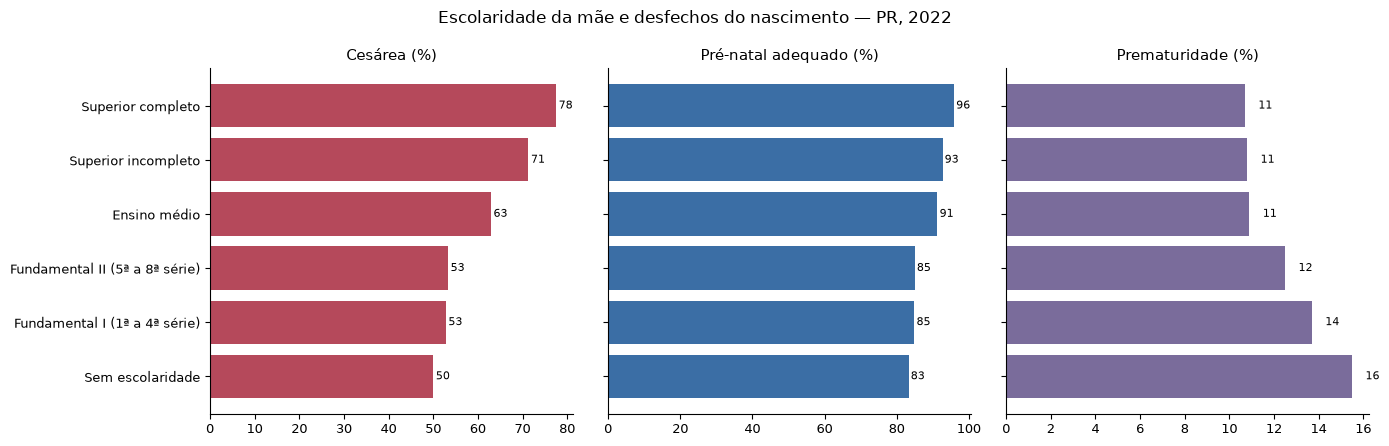

In [19]:
figura, eixos = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
metricas = [("Cesárea (%)", "#b5495b"),
            ("Pré-natal adequado (%)", "#3b6ea5"),
            ("Prematuridade (%)", "#7a6c9b")]

for eixo, (metrica, cor) in zip(eixos, metricas):
    eixo.barh(gradiente.index, gradiente[metrica], color=cor)
    eixo.set_title(metrica, fontsize=11)
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.tick_params(labelsize=9)
    for indice, valor in enumerate(gradiente[metrica]):
        eixo.text(valor + 0.6, indice, f"{valor:.0f}", va="center", fontsize=8)

plt.suptitle(f"Escolaridade da mãe e desfechos do nascimento — {UF}, {ANO}",
             fontsize=12)
plt.tight_layout()
plt.show()

O padrão é quase sempre o mesmo e vale a pena dizer em voz alta: a cesárea
**cresce** com a escolaridade, enquanto a prematuridade **cai**. Ou seja, o
excesso de cirurgia está concentrado onde há mais acesso, e o risco biológico
onde há menos. São dois problemas diferentes de saúde pública, no mesmo estado.

## 8. Idade da mãe: dois extremos

A gravidez na adolescência cai há duas décadas; a maternidade depois dos 35
sobe. As duas pontas exigem cuidados diferentes.

In [20]:
def perfil_etario(uf, ano):
    caminho = sinasc(uf, ano)[0].replace("\\", "/")
    dados = con.execute(f"""
        SELECT CAST(IDADEMAE AS INTEGER) AS idade, PARTO, PESO
        FROM read_parquet('{caminho}')
        WHERE TRY_CAST(IDADEMAE AS INTEGER) BETWEEN 10 AND 55
    """).df()
    peso = pd.to_numeric(dados["PESO"], errors="coerce")
    return {
        "Ano": ano,
        "Nascimentos": len(dados),
        "Mães até 19 anos (%)": round((dados["idade"] < 20).mean() * 100, 1),
        "Mães de 35 ou mais (%)": round((dados["idade"] >= 35).mean() * 100, 1),
        "Idade média": round(dados["idade"].mean(), 1),
        "Cesárea (%)": round(
            (dados["PARTO"].astype(str).str.strip() == "2").mean() * 100, 1),
        "Baixo peso (%)": round((peso < 2500).mean() * 100, 1),
    }

historico = pd.DataFrame([perfil_etario(UF, ano) for ano in serie])
historico

,Ano,Nascimentos,Mães até 19 anos (%),Mães de 35 ou mais (%),Idade média,Cesárea (%),Baixo peso (%)
0,2015,160946,16.8,13.2,26.5,61.4,8.4
1,2016,155061,15.5,14.0,26.8,61.4,8.5
2,2017,157695,14.2,14.9,27.0,62.0,8.4
3,2018,156199,13.2,15.9,27.3,61.9,8.5
4,2019,153466,12.3,16.5,27.5,62.3,8.8
5,2020,146287,11.3,16.9,27.6,64.9,8.7
6,2021,141974,11.1,16.9,27.7,64.6,8.9
7,2022,140636,10.0,17.2,27.9,64.8,9.4


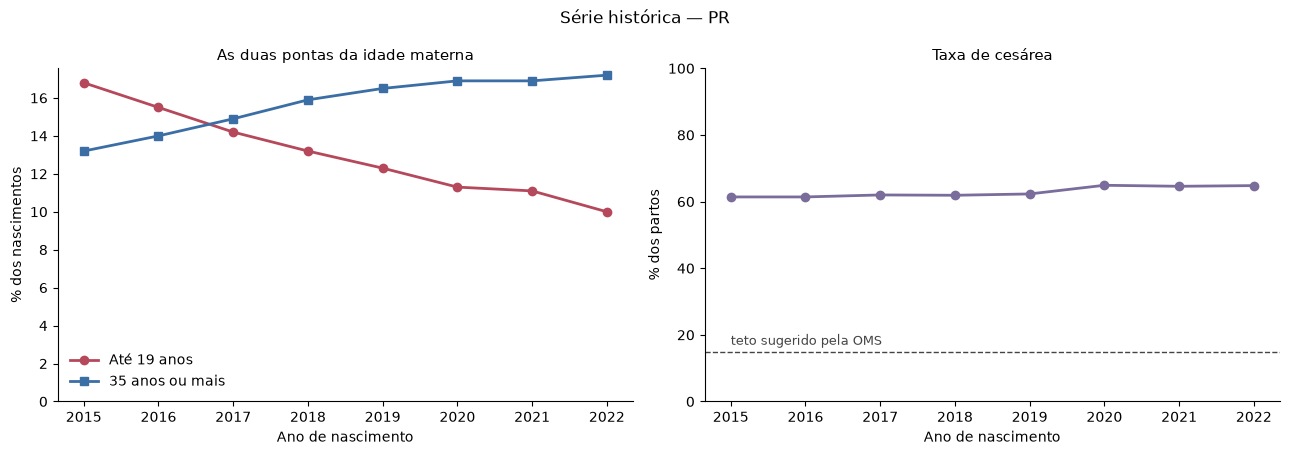

In [21]:
figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(13, 4.6))

eixo1.plot(historico["Ano"], historico["Mães até 19 anos (%)"],
           marker="o", color="#b5495b", linewidth=2, label="Até 19 anos")
eixo1.plot(historico["Ano"], historico["Mães de 35 ou mais (%)"],
           marker="s", color="#3b6ea5", linewidth=2, label="35 anos ou mais")
eixo1.set_ylabel("% dos nascimentos")
eixo1.set_title("As duas pontas da idade materna", fontsize=11)
eixo1.legend(frameon=False)
eixo1.set_ylim(bottom=0)

eixo2.plot(historico["Ano"], historico["Cesárea (%)"],
           marker="o", color="#7a6c9b", linewidth=2)
eixo2.set_ylabel("% dos partos")
eixo2.set_title("Taxa de cesárea", fontsize=11)
eixo2.axhline(15, color="#444", linestyle="--", linewidth=1)
eixo2.text(historico["Ano"].iloc[0], 17, "teto sugerido pela OMS",
           fontsize=9, color="#444")
eixo2.set_ylim(0, 100)

for eixo in (eixo1, eixo2):
    eixo.set_xlabel("Ano de nascimento")
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Série histórica — {UF}", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Conferindo com a realidade

In [22]:
apgar_baixo = None
if "APGAR5" in nascimentos:
    apgar = nascimentos["APGAR5"]
    valido = apgar.between(0, 10)
    apgar_baixo = (apgar[valido] < 7).mean() * 100

print("Verificações de sanidade\n")
print(f"1. Nascimentos no ano                {mil(len(nascimentos))}")
print(f"2. Taxa de cesárea entre 40% e 75%?  {taxa_cesarea:.1f}% "
      f"({'sim' if 40 < taxa_cesarea < 75 else 'ATENÇÃO'})")
print(f"3. Prematuridade entre 8% e 15%?     "
      f"{indicadores['Prematuridade (< 37 semanas)']:.1f}% "
      f"({'sim' if 8 < indicadores['Prematuridade (< 37 semanas)'] < 15 else 'ATENÇÃO'})")
print(f"4. Baixo peso entre 6% e 12%?        "
      f"{indicadores['Baixo peso (< 2.500 g)']:.1f}% "
      f"({'sim' if 6 < indicadores['Baixo peso (< 2.500 g)'] < 12 else 'ATENÇÃO'})")
if apgar_baixo is not None:
    print(f"5. Apgar do 5º minuto abaixo de 7    {apgar_baixo:.1f}% "
          f"(o esperado é de 1% a 2%)")
print()
print("Peso médio ao nascer:", f"{nascimentos.loc[com_peso, 'PESO'].mean():.0f} g",
      "(o esperado no Brasil é entre 3.100 e 3.250 g)")

Verificações de sanidade

1. Nascimentos no ano                140.637
2. Taxa de cesárea entre 40% e 75%?  64.8% (sim)
3. Prematuridade entre 8% e 15%?     11.2% (sim)
4. Baixo peso entre 6% e 12%?        9.4% (sim)
5. Apgar do 5º minuto abaixo de 7    1.0% (o esperado é de 1% a 2%)

Peso médio ao nascer: 3146 g (o esperado no Brasil é entre 3.100 e 3.250 g)


## 10. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "SP"` |
| Um município | filtre `nascimentos["CODMUNRES"] == "4106902"` |
| Comparar hospitais | agrupe por `CODESTAB` (acrescente a coluna em `INTERESSE`) |
| Só a rede pública | cruze `CODESTAB` com o CNES, pelo notebook da rede assistencial |
| Nascimentos por raça/cor | agrupe por `RACACOR` em vez de `ESCMAE2010` |
| Gemelares | filtre `GRAVIDEZ` diferente de `"1"` |

### O que vale levar

A tabela de Robson pronta é o material mais reaproveitável daqui: é com ela
que se conversa com uma maternidade sobre a própria taxa de cesárea sem que a
conversa vire acusação.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: SINASC/DATASUS, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*